In [2]:
# =========================================
# HEALTHCARE READMISSION PREDICTION
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression


# -----------------------------------------
# 1. LOAD DATA
# -----------------------------------------
df = pd.read_csv("/content/hospital_records.csv")
print(df.head())




  patient_id  age gender        department admission_date  \
0   PT000000   63      F        Cardiology     27-05-2022   
1   XXXX0001   52      M        cardiology     28/02/2023   
2   PT000002   66      F        Cardiology     2022-10-09   
3   PT000003   82      M         Neurology     25-07-2023   
4   PT000004   50      m  General Medicine     10/04/2023   

   length_of_stay_days  systolic_bp  diastolic_bp  glucose_mg_dl  \
0                    1        135.0          96.0          121.7   
1                    0        142.0         105.0          145.3   
2                    1        122.0          79.0          128.6   
3                    1        137.0         105.0           72.7   
4                   11        116.0          81.0          142.6   

   creatinine_mg_dl   bmi  num_medications  num_diagnoses insurance_type  \
0              0.73  22.5                7              6        Private   
1              0.86  27.5               10              7        Private

In [3]:
# -----------------------------------------
# 2. CLEAN DATA
# -----------------------------------------
# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Fix negative values
for col in df.select_dtypes(include=np.number):
    df[col] = df[col].apply(lambda x: x if x >= 0 else np.nan)
    df[col] = df[col].fillna(df[col].median())

# Encode categorical
df = pd.get_dummies(df, drop_first=True)




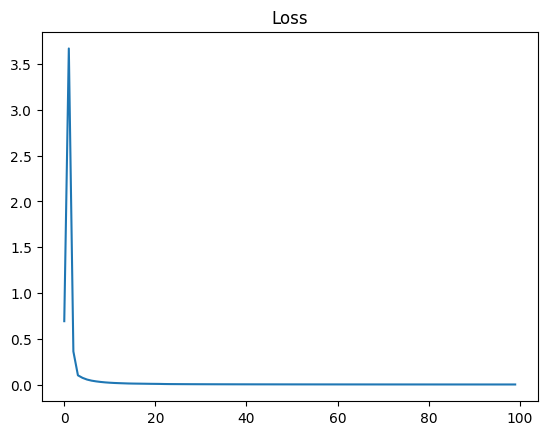

In [4]:
# -----------------------------------------
# 3. PREPARE DATA
# -----------------------------------------
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -----------------------------------------
# 4. SIMPLE NEURAL NETWORK
# -----------------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Initialize
np.random.seed(42)
W1 = np.random.randn(X_train.shape[1], 16) * 0.01
b1 = np.zeros((1, 16))
W2 = np.random.randn(16, 1) * 0.01
b2 = np.zeros((1, 1))

# Train
losses = []
y_train = y_train.values.reshape(-1, 1)

for i in range(100):
    # Forward
    A1 = sigmoid(np.dot(X_train, W1) + b1)
    A2 = sigmoid(np.dot(A1, W2) + b2)

    # Loss
    loss = -np.mean(y_train*np.log(A2+1e-8) + (1-y_train)*np.log(1-A2+1e-8))
    losses.append(loss)

    # Backprop
    dZ2 = A2 - y_train
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0)

    dZ1 = np.dot(dZ2, W2.T) * A1*(1-A1)
    dW1 = np.dot(X_train.T, dZ1)
    db1 = np.sum(dZ1, axis=0)

    # Update
    lr = 0.01
    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2


# Plot loss
plt.plot(losses)
plt.title("Loss")
plt.show()



In [5]:

# -----------------------------------------
# 5. EVALUATION
# -----------------------------------------
def predict(X, t=0.5):
    A1 = sigmoid(np.dot(X, W1) + b1)
    A2 = sigmoid(np.dot(A1, W2) + b2)
    return (A2 > t).astype(int)

y_pred = predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


# -----------------------------------------
# 6. BASELINE MODEL
# -----------------------------------------
model = LogisticRegression()
model.fit(X_train, y_train.ravel())

print("Logistic F1:", f1_score(y_test, model.predict(X_test)))


# -----------------------------------------
# 7. COST OPTIMIZATION
# -----------------------------------------
def cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp*1 + fn*10

thresholds = np.linspace(0.1, 0.9, 20)
best_t = thresholds[np.argmin([cost(y_test, predict(X_test, t)) for t in thresholds])]

print("Best threshold:", best_t)

F1 Score: 0.45517241379310347
Confusion Matrix:
 [[176 150]
 [  8  66]]
Logistic F1: 0.024096385542168676
Best threshold: 0.6894736842105262
